## Test generatore exp e CL
Innanzitutto, testiamo il generatore di numeri casuali con distribuzione esponenziale e distribuzione di Cauchy-Lorentz, ottenuto tramite il metodo dell'inversione della cumulativa

Aggiungere formule della cumulativa e inversa (per entrambi i casi)

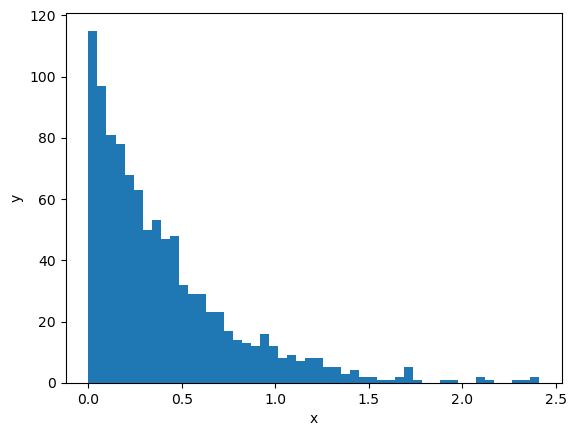

In [2]:
import numpy as np
import matplotlib.pyplot as plt

chi2 = np.loadtxt("test_exp.dat")
plt.hist(chi2, bins=50)

plt.xlabel("x")
plt.ylabel("y")

plt.show()


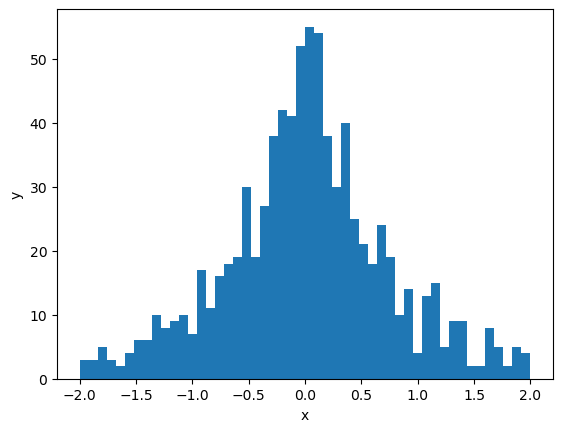

In [10]:
import numpy as np
import matplotlib.pyplot as plt

chi2 = np.loadtxt("test_CL.dat")
plt.hist(chi2, bins=50, range=(-2,2))

plt.xlabel("x")
plt.ylabel("y")

plt.show()

## Distribuzioni

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

# Lista dei file e distribuzioni
files = ["unif.dat", "exp.dat", "CL.dat"]
distributions = ["Uniform", "Exponential", "Cauchy-Lorentz"]
N_values = [1, 2, 10, 100]

# Parametri istogramma
bins = 50  # numero di bins

for idx, file in enumerate(files):
    data = np.loadtxt(file)  # legge il file in un array Mx4
    fig, axs = plt.subplots(2,2, figsize=(10,8))  # 4 subplot per N

    for j, N in enumerate(N_values):
        SN = data[:,j]  # seleziona la colonna corrispondente a N

        # determina quale subplot usare
        ax = axs[j//2, j%2]

        # calcola min e max dei dati per adattare il range
        min_val = np.min(SN)
        max_val = np.max(SN)

        # crea istogramma con range automatico
        ax.hist(SN, bins=bins, range=(min_val, max_val), density=True,
                alpha=0.7, color='skyblue', edgecolor='black')

        if N == 100:
            x = np.linspace(min_val, max_val, 1000)  # asse x per la curva
            if distributions[idx] in ["Uniform", "Exponential"]:
                # fit gaussiano
                mu = np.mean(SN)
                sigma = np.std(SN)
                y = norm.pdf(x, loc=mu, scale=sigma)
            else:  # Cauchy-Lorentz
                mu = np.median(SN)  # centro della distribuzione
                gamma = np.std(SN)  # scala approssimativa
                y = cauchy.pdf(x, loc=mu, scale=gamma)

            ax.plot(x, y, 'r', lw=2)  # curva rossa sovrapposta
            
        ax.set_title(f"N = {N}")
        ax.set_xlabel("S_N")
        ax.set_ylabel("Density")

    fig.suptitle(f"{distributions[idx]} Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

 

NameError: name 'files' is not defined